In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf
import yfinance as yf
import seaborn as sns

print("All libraries loaded successfully!")


All libraries loaded successfully!


In [2]:
df = yf.download("GC=F", start="2021-01-01", end="2025-12-31")

# Clean it up
df = df.dropna()

print(df.shape)   # tells you how many rows of data you have
print(df.head())  # shows first 5 rows

[*********************100%***********************]  1 of 1 completed

(1256, 5)
Price             Close         High          Low         Open Volume
Ticker             GC=F         GC=F         GC=F         GC=F   GC=F
Date                                                                 
2021-01-04  1944.699951  1945.099976  1912.199951  1912.199951    154
2021-01-05  1952.699951  1952.699951  1941.300049  1941.699951    113
2021-01-06  1906.900024  1959.900024  1901.500000  1952.000000    331
2021-01-07  1912.300049  1926.699951  1912.000000  1922.599976    122
2021-01-08  1834.099976  1908.000000  1834.099976  1908.000000     60


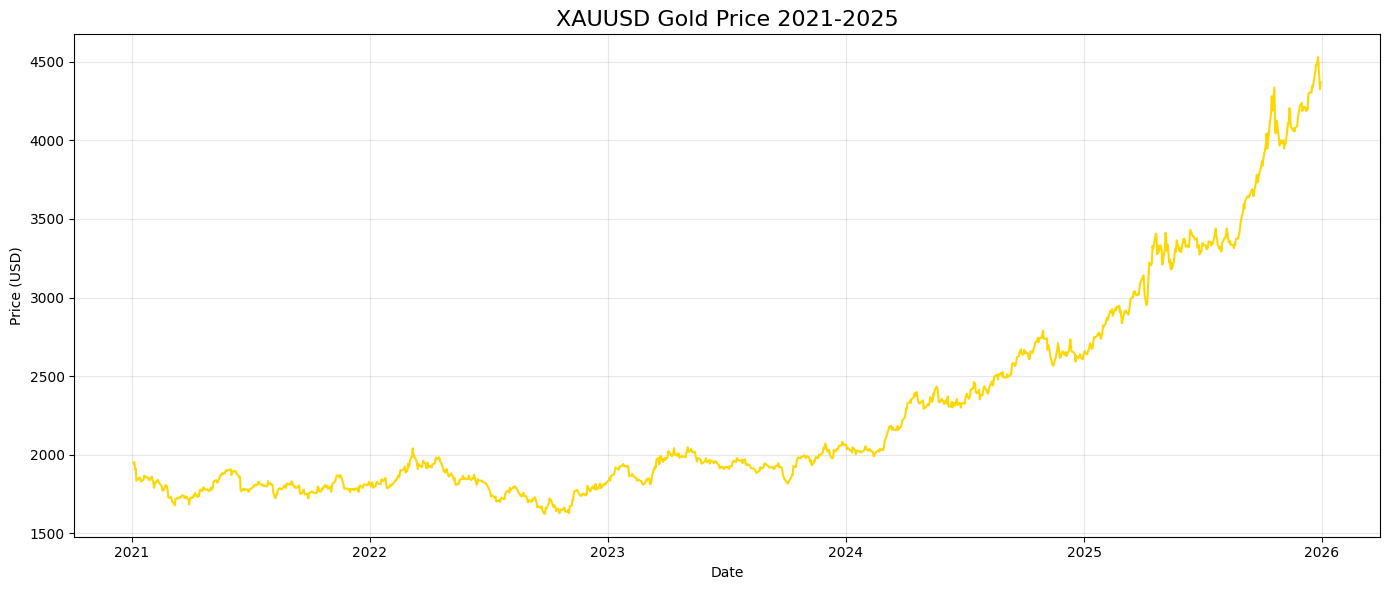

In [3]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], color='gold', linewidth=1.5)
plt.title('XAUUSD Gold Price 2021-2025', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

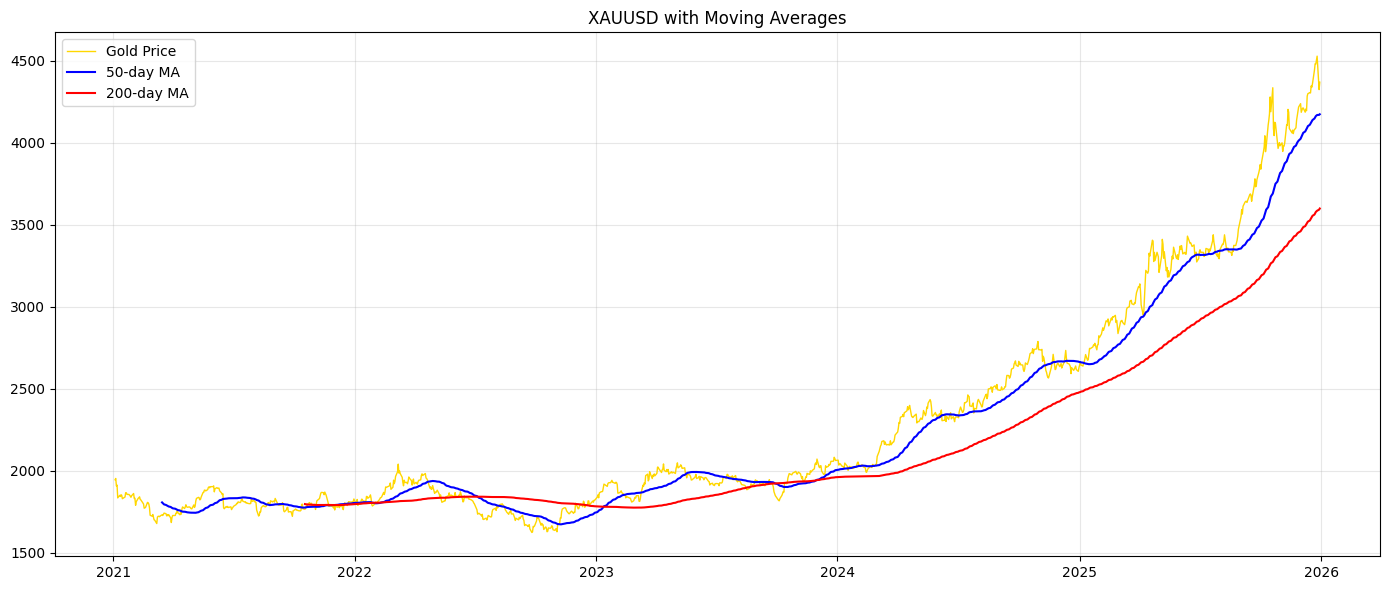

In [4]:
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(14, 6))
plt.plot(df['Close'], label='Gold Price', color='gold', linewidth=1)
plt.plot(df['MA50'], label='50-day MA', color='blue', linewidth=1.5)
plt.plot(df['MA200'], label='200-day MA', color='red', linewidth=1.5)
plt.title('XAUUSD with Moving Averages')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


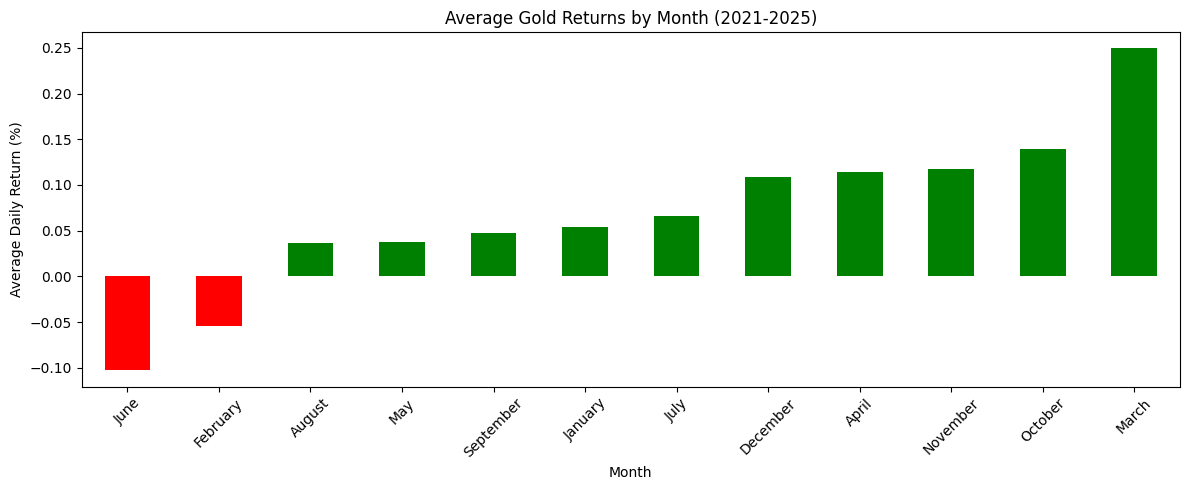

In [5]:
df['Month'] = df.index.month_name()
df['Year'] = df.index.year
df['Daily_Return'] = df['Close'].pct_change() * 100

monthly_avg = df.groupby('Month')['Daily_Return'].mean().sort_values()

plt.figure(figsize=(12, 5))
colors = ['red' if x < 0 else 'green' for x in monthly_avg]
monthly_avg.plot(kind='bar', color=colors)
plt.title('Average Gold Returns by Month (2021-2025)')
plt.xlabel('Month')
plt.ylabel('Average Daily Return (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


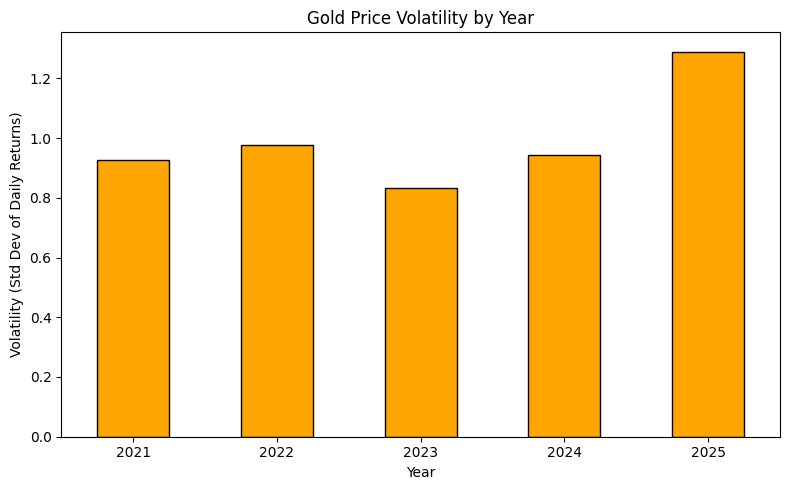

In [6]:
yearly_volatility = df.groupby('Year')['Daily_Return'].std()

plt.figure(figsize=(8, 5))
yearly_volatility.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Gold Price Volatility by Year')
plt.xlabel('Year')
plt.ylabel('Volatility (Std Dev of Daily Returns)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


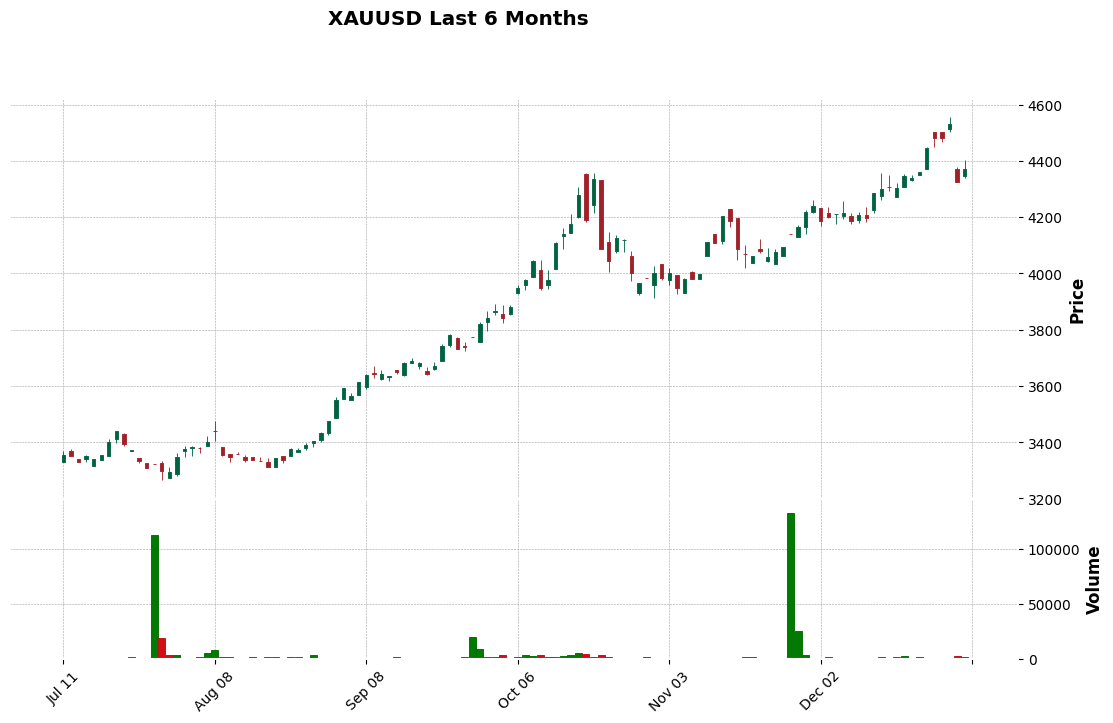

In [7]:
# Take just last 6 months for candlestick
df_candle = df[['Open','High','Low','Close','Volume']].tail(120)

# Fix column names for mplfinance
df_candle.columns = ['Open','High','Low','Close','Volume']

mpf.plot(df_candle,
         type='candle',
         style='charles',
         title='XAUUSD Last 6 Months',
         volume=True,
         figsize=(14, 8))


In [8]:
close_col = df['Close']

# If df['Close'] returns multiple columns (DataFrame), take first one
if isinstance(close_col, pd.DataFrame):
    close_col = close_col.iloc[:, 0]

high_col = df['High']
if isinstance(high_col, pd.DataFrame):
    high_col = high_col.iloc[:, 0]

low_col = df['Low']
if isinstance(low_col, pd.DataFrame):
    low_col = low_col.iloc[:, 0]

daily_return_col = df['Daily_Return']
if isinstance(daily_return_col, pd.DataFrame):
    daily_return_col = daily_return_col.iloc[:, 0]


print("=" * 45)
print("       XAUUSD ANALYSIS SUMMARY")
print("=" * 45)

print("Period         : 2021 - 2025")
print(f"Starting Price : ${close_col.iloc[0]:.2f}")
print(f"Ending Price   : ${close_col.iloc[-1]:.2f}")
print(f"All-Time High  : ${high_col.max():.2f}")
print(f"All-Time Low   : ${low_col.min():.2f}")
print(f"Best Day       : {daily_return_col.max():.2f}%")
print(f"Worst Day      : {daily_return_col.min():.2f}%")
print(f"Avg Daily Move : {daily_return_col.abs().mean():.2f}%")

print("=" * 45)

       XAUUSD ANALYSIS SUMMARY
Period         : 2021 - 2025
Starting Price : $1944.70
Ending Price   : $4370.10
All-Time High  : $4556.30
All-Time Low   : $1615.10
Best Day       : 3.50%
Worst Day      : -5.74%
Avg Daily Move : 0.74%


In [9]:
df['Trend'] = np.where(df['MA50'] > df['MA200'], 'Bullish',
              np.where(df['MA50'] < df['MA200'], 'Bearish', 'Sideways'))

print(df[['MA50', 'MA200', 'Trend']].tail(10))
print("\nCurrent Market Trend:", df['Trend'].iloc[-1])

Price              MA50        MA200    Trend
Ticker                                       
Date                                         
2025-12-16  4117.625986  3533.492992  Bullish
2025-12-17  4125.043984  3540.653992  Bullish
2025-12-18  4130.967983  3547.768491  Bullish
2025-12-19  4139.269980  3555.051991  Bullish
2025-12-22  4148.643984  3562.819991  Bullish
2025-12-23  4156.127979  3570.669491  Bullish
2025-12-24  4162.965977  3578.376991  Bullish
2025-12-26  4170.009980  3586.100991  Bullish
2025-12-29  4170.907979  3592.753992  Bullish
2025-12-30  4174.511982  3599.604492  Bullish

Current Market Trend: Bullish


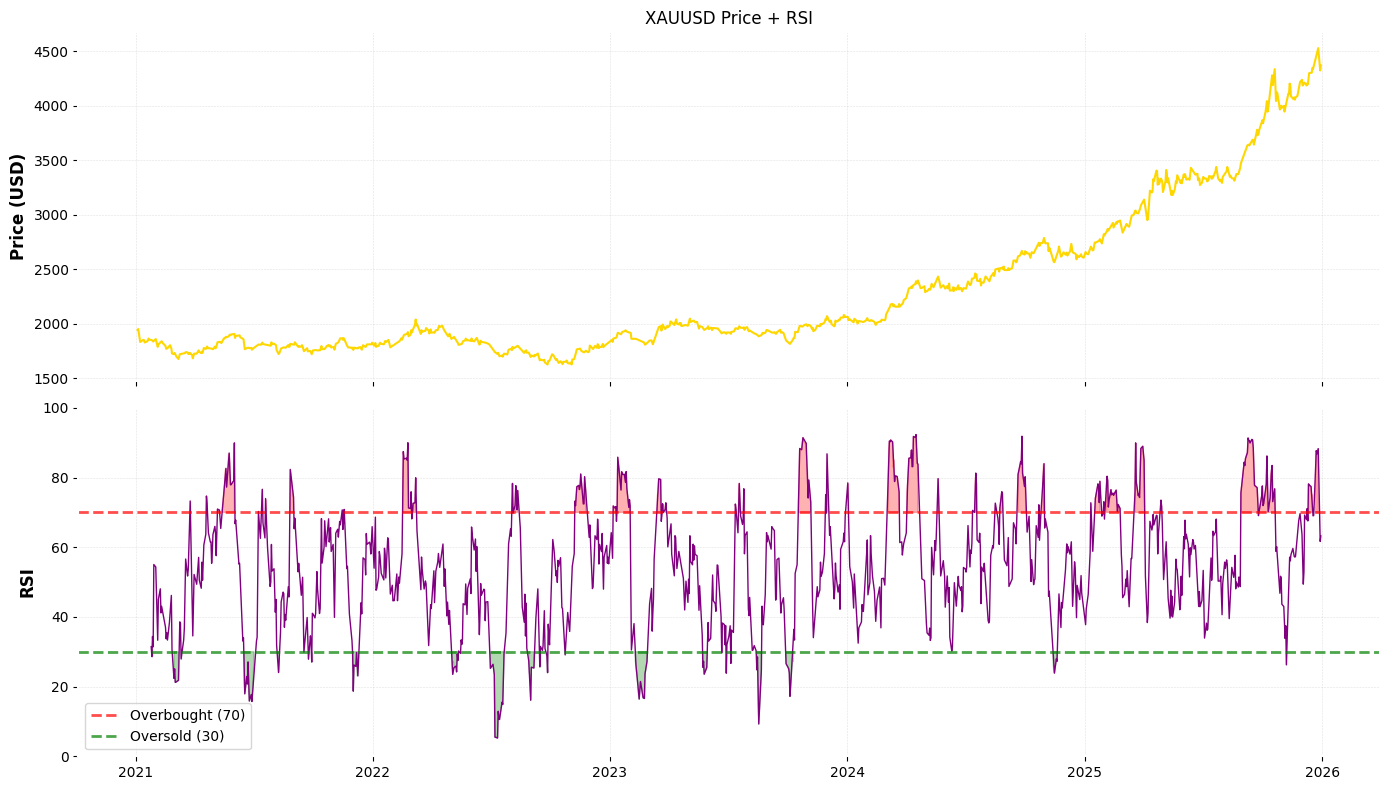

In [10]:
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = -delta.clip(upper=0).rolling(period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI'] = compute_rsi(df['Close'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(df['Close'], color='gold', linewidth=1.5)
ax1.set_title('XAUUSD Price + RSI')
ax1.set_ylabel('Price (USD)')
ax1.grid(True, alpha=0.3)

ax2.plot(df['RSI'], color='purple', linewidth=1)
ax2.axhline(70, color='red', linestyle='--', alpha=0.7, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', alpha=0.7, label='Oversold (30)')
ax2.fill_between(df.index, df['RSI'], 70, where=(df['RSI']>=70), alpha=0.3, color='red')
ax2.fill_between(df.index, df['RSI'], 30, where=(df['RSI']<=30), alpha=0.3, color='green')
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

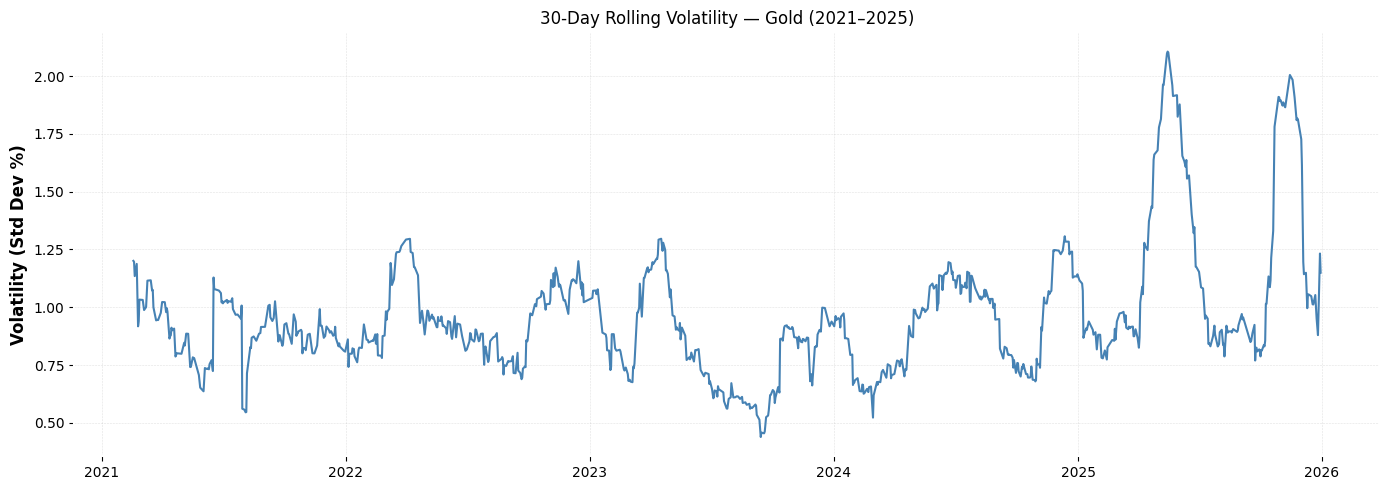

In [11]:
df['RollingVol30'] = df['Daily_Return'].rolling(30).std()

plt.figure(figsize=(14, 5))
plt.plot(df.index, df['RollingVol30'], color='steelblue', linewidth=1.5)
plt.title('30-Day Rolling Volatility — Gold (2021–2025)')
plt.ylabel('Volatility (Std Dev %)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

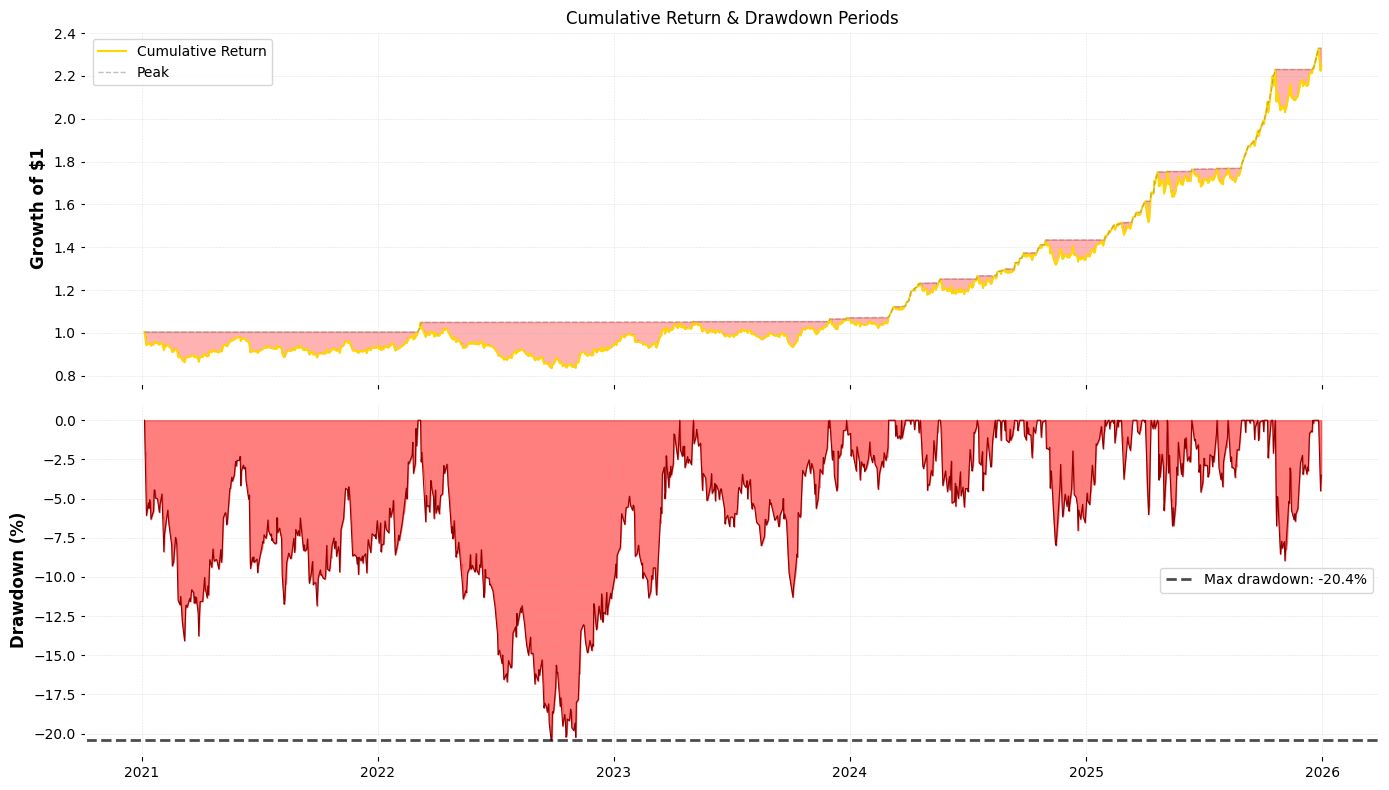


Maximum Drawdown: -20.43%
Worst point: September 2022


In [12]:
cumulative = (1 + df['Daily_Return'] / 100).cumprod()
rolling_max = cumulative.cummax()
drawdown = (cumulative - rolling_max) / rolling_max * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(cumulative, color='gold', linewidth=1.5, label='Cumulative Return')
ax1.plot(rolling_max, color='gray', linewidth=1, linestyle='--', alpha=0.5, label='Peak')
ax1.fill_between(cumulative.index, cumulative, rolling_max,
                 where=(cumulative < rolling_max), alpha=0.3, color='red')
ax1.set_title('Cumulative Return & Drawdown Periods')
ax1.set_ylabel('Growth of $1')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.fill_between(drawdown.index, drawdown, 0, alpha=0.5, color='red')
ax2.plot(drawdown, color='darkred', linewidth=0.8)
ax2.axhline(drawdown.min(), color='black', linestyle='--', alpha=0.7,
            label=f'Max drawdown: {drawdown.min():.1f}%')
ax2.set_ylabel('Drawdown (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"\nMaximum Drawdown: {drawdown.min():.2f}%")
print(f"Worst point: {drawdown.idxmin().strftime('%B %Y')}")


In [13]:
close = df['Close']

# If Close is still a DataFrame, take first column
if isinstance(close, pd.DataFrame):
    close = close.iloc[:, 0]

start_price = close.iloc[0]
end_price = close.iloc[-1]

years = (df.index[-1] - df.index[0]).days / 365.25

cagr = ((end_price / start_price) ** (1 / years) - 1) * 100

print(f"Start Price : ${start_price:.2f}")
print(f"End Price   : ${end_price:.2f}")
print(f"CAGR        : {cagr:.2f}% per year")

Start Price : $1944.70
End Price   : $4370.10
CAGR        : 17.63% per year


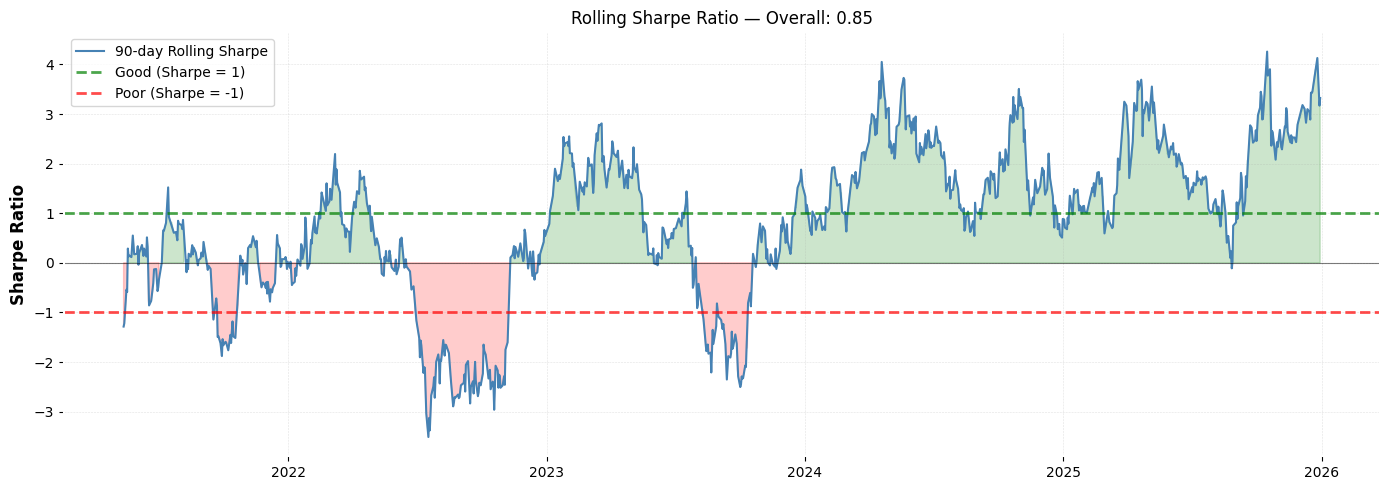


Overall Sharpe Ratio: 0.85
Sharpe > 1 = Good | > 2 = Very good | < 0 = Poor


In [14]:
risk_free_rate = 0.04 / 252
excess_returns = df['Daily_Return'] / 100 - risk_free_rate
sharpe = (excess_returns.mean() / excess_returns.std()) * np.sqrt(252)

rolling_sharpe = excess_returns.rolling(90).apply(
    lambda x: (x.mean() / x.std()) * np.sqrt(252) if x.std() > 0 else 0
)

plt.figure(figsize=(14, 5))
plt.plot(rolling_sharpe, color='steelblue', linewidth=1.5, label='90-day Rolling Sharpe')
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.axhline(1, color='green', linestyle='--', alpha=0.7, label='Good (Sharpe = 1)')
plt.axhline(-1, color='red', linestyle='--', alpha=0.7, label='Poor (Sharpe = -1)')
plt.fill_between(rolling_sharpe.index, rolling_sharpe, 0,
                 where=(rolling_sharpe >= 0), alpha=0.2, color='green')
plt.fill_between(rolling_sharpe.index, rolling_sharpe, 0,
                 where=(rolling_sharpe < 0), alpha=0.2, color='red')
plt.title(f'Rolling Sharpe Ratio — Overall: {sharpe:.2f}')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nOverall Sharpe Ratio: {sharpe:.2f}")
print("Sharpe > 1 = Good | > 2 = Very good | < 0 = Poor")


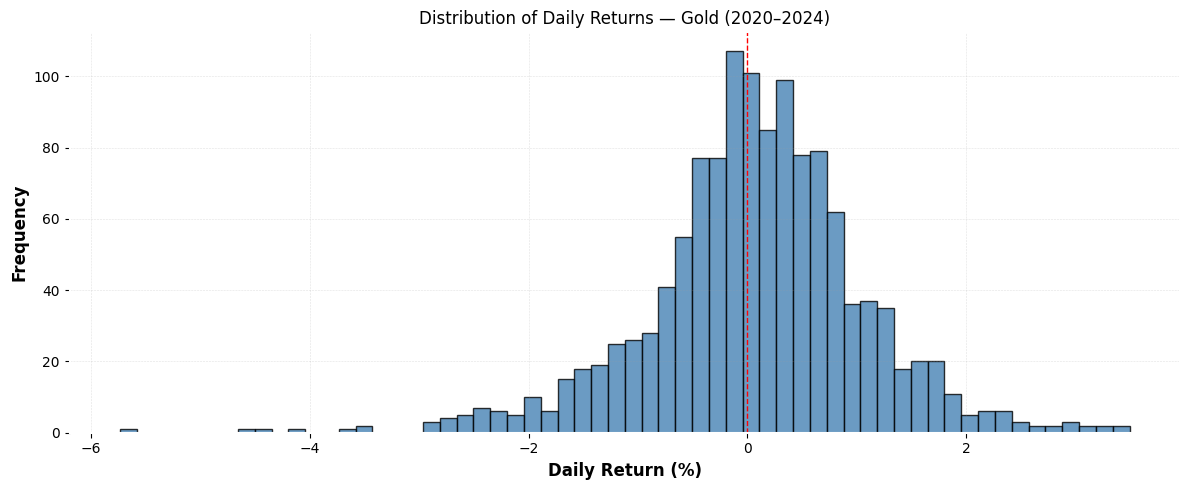

In [15]:
plt.figure(figsize=(12, 5))
plt.hist(df['Daily_Return'].dropna(), bins=60, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.title('Distribution of Daily Returns — Gold (2020–2024)')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


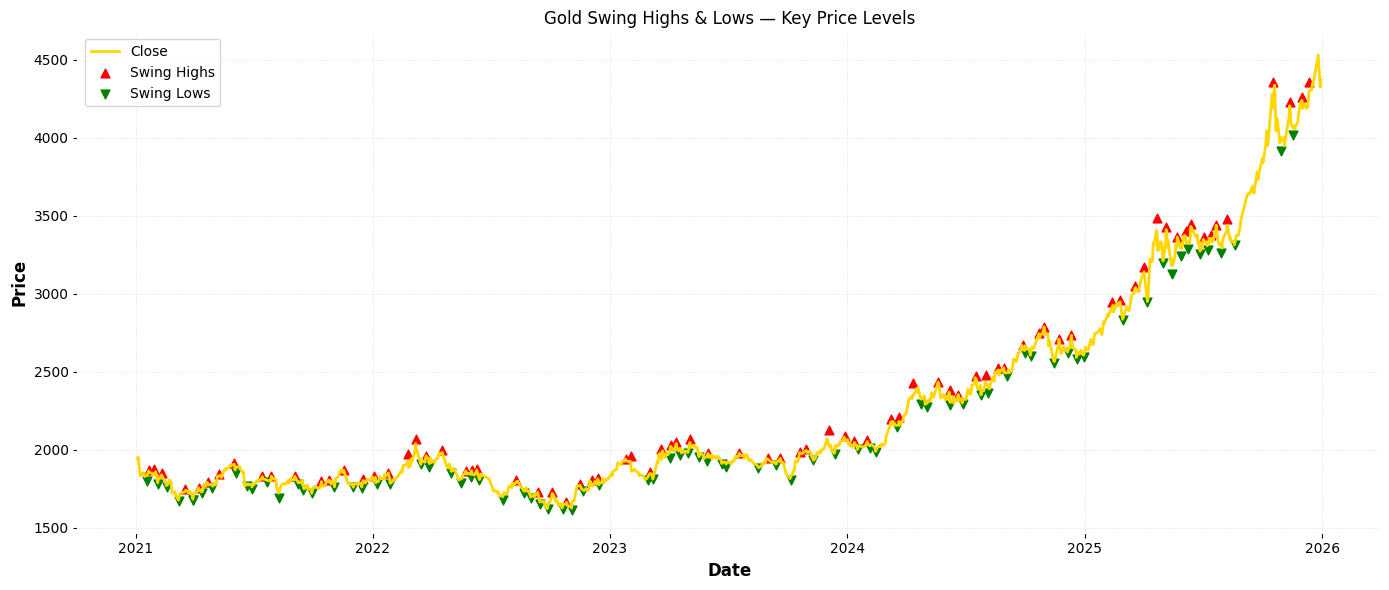

In [16]:
window = 10
df['SwingHigh'] = df['High'][(df['High'] == df['High'].rolling(window, center=True).max())]
df['SwingLow'] = df['Low'][(df['Low'] == df['Low'].rolling(window, center=True).min())]

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Close', color='gold')
plt.scatter(df.index, df['SwingHigh'], color='red', label='Swing Highs', marker='^', s=40)
plt.scatter(df.index, df['SwingLow'], color='green', label='Swing Lows', marker='v', s=40)
plt.title('Gold Swing Highs & Lows — Key Price Levels')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [17]:
levels = pd.concat([df['SwingHigh'].dropna(), df['SwingLow'].dropna()])
levels = levels.round(0)
top_levels = levels.value_counts().head(10)

print("Top 10 Most Repeated Key Levels:\n")
print(top_levels)


Top 10 Most Repeated Key Levels:

1876.0    2
1794.0    2
1833.0    2
1809.0    2
1853.0    2
2072.0    2
1805.0    2
1728.0    2
1779.0    2
1808.0    2
Name: count, dtype: int64


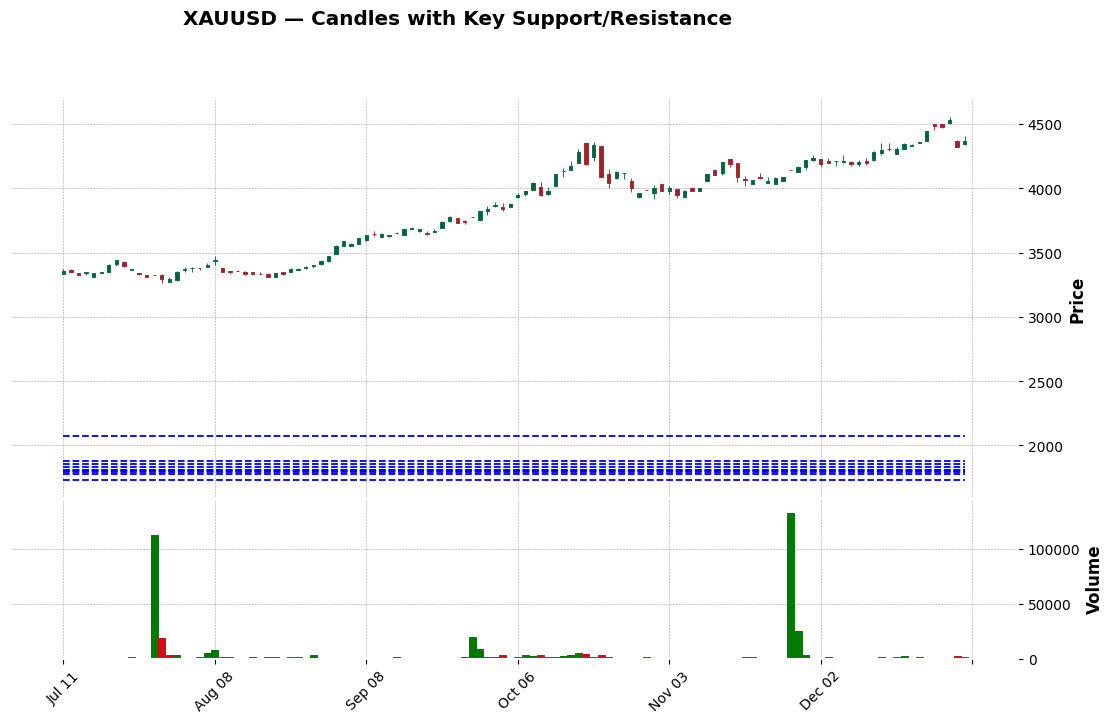

In [18]:
key_levels = top_levels.index.tolist()
add_lines = [mpf.make_addplot([level]*len(df_candle), color='blue', linestyle='--')
             for level in key_levels]

mpf.plot(df_candle, type='candle', style='charles',
         title='XAUUSD — Candles with Key Support/Resistance',
         volume=True, addplot=add_lines, figsize=(14, 8))


In [19]:
assets = {
    'Gold':    'GC=F',
    'S&P 500': 'SPY',
    'USD Index':'DX-Y.NYB',
    'Oil':     'CL=F',
    'Bitcoin': 'BTC-USD',
    'Silver':  'SI=F',
}

prices = pd.DataFrame()
for name, ticker in assets.items():
    try:
        data = yf.download(ticker, start="2020-01-01", end="2024-12-31", progress=False)['Close']
        prices[name] = data
    except:
        print(f"Could not fetch {ticker}")

corr_matrix = prices.pct_change().dropna().corr()

corr_gold_sp = corr_matrix.loc['Gold', 'S&P 500']
corr_gold_dxy = corr_matrix.loc['Gold', 'USD Index']
print(f"Correlation Gold vs S&P500   : {corr_gold_sp:.2f}")
print(f"Correlation Gold vs USD Index: {corr_gold_dxy:.2f}")


Correlation Gold vs S&P500   : 0.13
Correlation Gold vs USD Index: -0.39


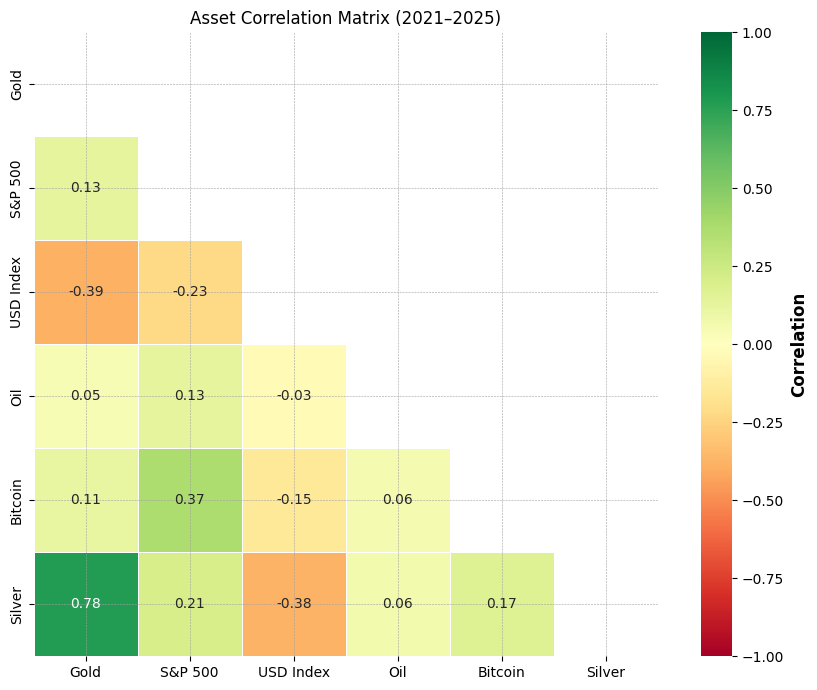

In [20]:
plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, mask=mask,
            cbar_kws={'label': 'Correlation'})
plt.title('Asset Correlation Matrix (2021–2025)')
plt.tight_layout()
plt.show()


In [21]:


df = df.loc[:, ~df.columns.duplicated()]


if isinstance(df.columns, pd.MultiIndex):
    df.columns = ['_'.join(col).strip() for col in df.columns.values]


close_col = [col for col in df.columns if "Close" in col]
high_col  = [col for col in df.columns if "High" in col]

if len(close_col) == 0:
    raise ValueError("❌ No Close column found in dataframe!")

if len(high_col) == 0:
    raise ValueError("❌ No High column found in dataframe!")


close_col = close_col[0]
high_col = high_col[0]


df[close_col] = pd.to_numeric(df[close_col], errors="coerce")
df[high_col] = pd.to_numeric(df[high_col], errors="coerce")

df = df.dropna(subset=[close_col, high_col])


print("=" * 60)
print(f"Period          : {df.index.min().date()} → {df.index.max().date()}")
print(f"Starting Price  : ${df[close_col].iloc[0]:.2f}")
print(f"Ending Price    : ${df[close_col].iloc[-1]:.2f}")
print(f"All-Time High   : ${df[high_col].max():.2f}")
print("=" * 60)

print(f"✅ Close Column Used: {close_col}")
print(f"✅ High Column Used : {high_col}")

Period          : 2021-01-04 → 2025-12-30
Starting Price  : $1944.70
Ending Price    : $4370.10
All-Time High   : $4556.30
✅ Close Column Used: Close_GC=F
✅ High Column Used : High_GC=F


✅ Using columns:
Close column: Close_GC=F
High column : High_GC=F


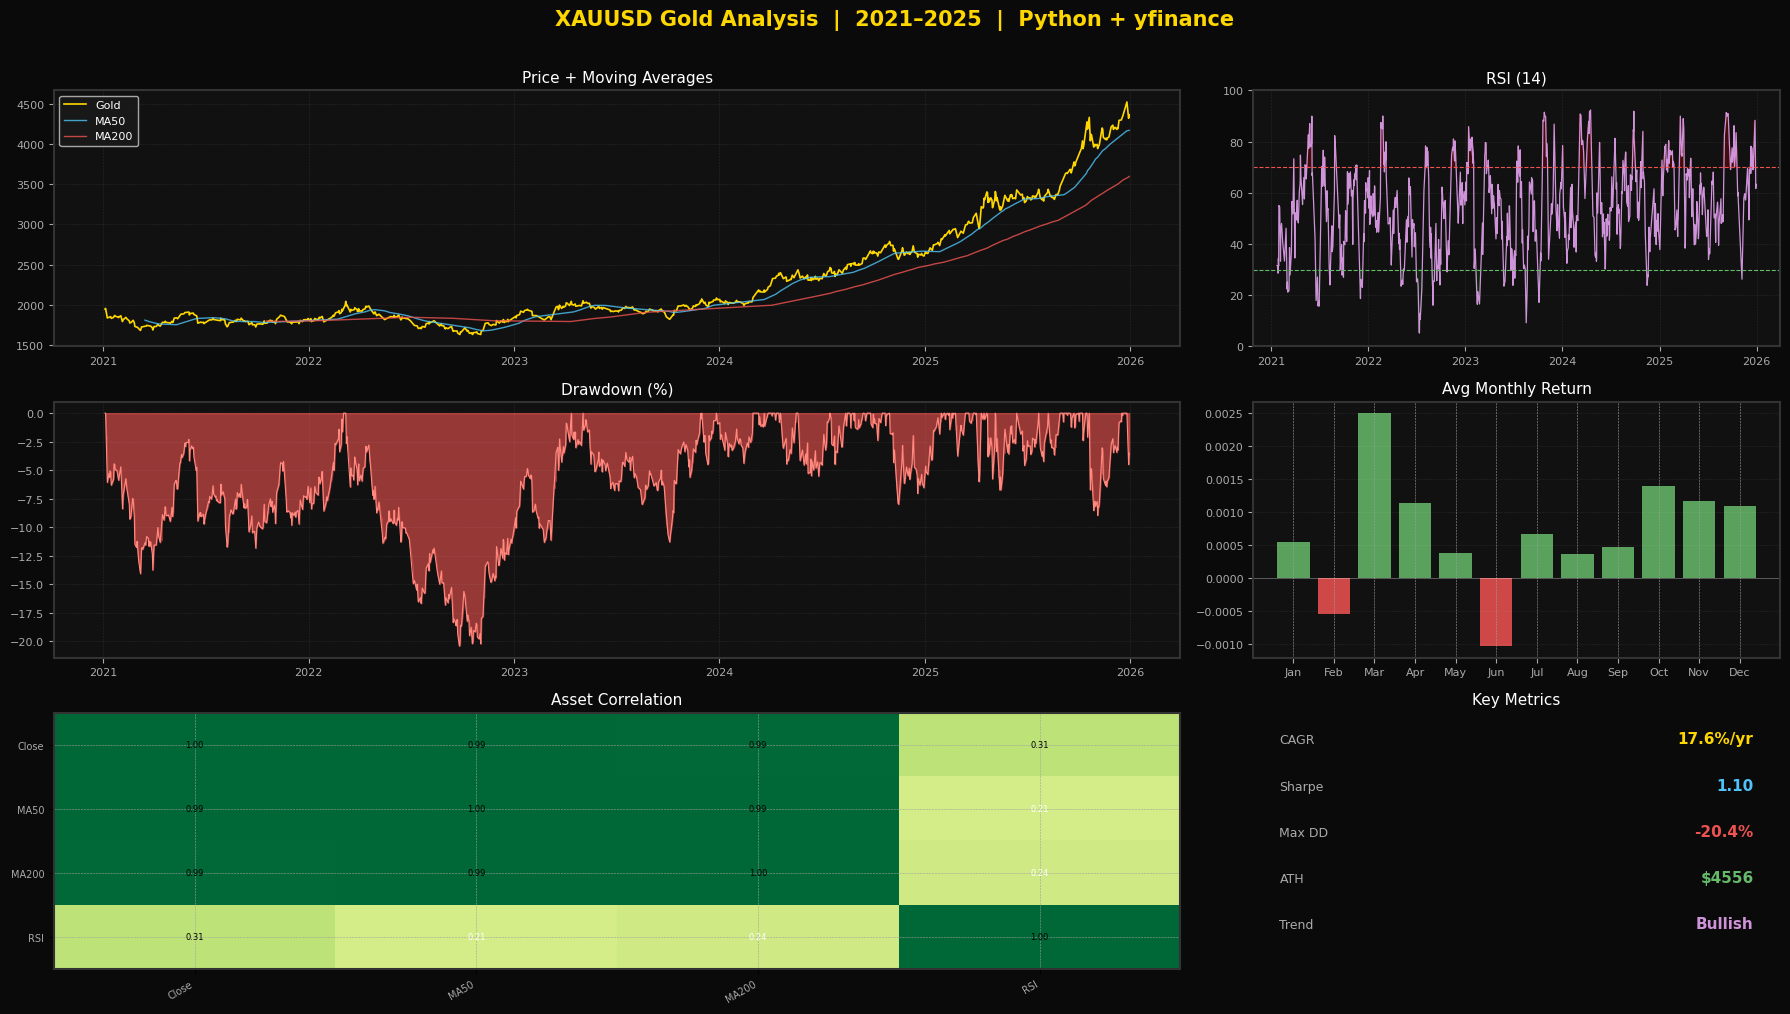

In [22]:


# ----------------------------
# CLEANING THE DATAFRAME
# ----------------------------

# Remove duplicate columns
df = df.loc[:, ~df.columns.duplicated()]

# Flatten MultiIndex columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = ['_'.join(col).strip() for col in df.columns.values]

# Detect Close and High columns
close_candidates = [c for c in df.columns if "Close" in c]
high_candidates  = [c for c in df.columns if "High" in c]

if len(close_candidates) == 0:
    raise ValueError(f"❌ Close column not found! Available columns: {df.columns}")

if len(high_candidates) == 0:
    raise ValueError(f"❌ High column not found! Available columns: {df.columns}")

close_col = close_candidates[0]
high_col  = high_candidates[0]

# Rename them into standard names
df = df.rename(columns={close_col: "Close", high_col: "High"})

# Convert to numeric
df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
df["High"]  = pd.to_numeric(df["High"], errors="coerce")

# Drop missing values
df = df.dropna(subset=["Close", "High"])

print("✅ Using columns:")
print("Close column:", close_col)
print("High column :", high_col)

# ----------------------------
# ADD INDICATORS
# ----------------------------

# Moving Averages
df["MA50"] = df["Close"].rolling(50).mean()
df["MA200"] = df["Close"].rolling(200).mean()

# RSI (14)
delta = df["Close"].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
df["RSI"] = 100 - (100 / (1 + rs))

# Daily Return
df["Daily_Return"] = df["Close"].pct_change()

# Month Short
df["MonthShort"] = df.index.strftime("%b")

# Trend
df["Trend"] = np.where(df["MA50"] > df["MA200"], "Bullish", "Bearish")

# Drawdown
rolling_max = df["Close"].cummax()
drawdown = ((df["Close"] - rolling_max) / rolling_max) * 100

# CAGR
years = (df.index.max() - df.index.min()).days / 365.25
cagr = ((df["Close"].iloc[-1] / df["Close"].iloc[0]) ** (1/years) - 1) * 100

# Sharpe Ratio
sharpe = (df["Daily_Return"].mean() / df["Daily_Return"].std()) * np.sqrt(252)

# Correlation matrix
corr_matrix = df[["Close", "MA50", "MA200", "RSI"]].corr()

# ----------------------------
# DASHBOARD PLOTTING
# ----------------------------

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#0a0a0a')

ax1 = fig.add_subplot(3, 3, (1, 2))
ax1.set_facecolor('#111111')
ax1.plot(df['Close'], color='#FFD700', linewidth=1.2, label='Gold')
ax1.plot(df['MA50'], color='#4fc3f7', linewidth=1, alpha=0.8, label='MA50')
ax1.plot(df['MA200'], color='#ef5350', linewidth=1, alpha=0.8, label='MA200')
ax1.set_title('Price + Moving Averages', color='white', fontsize=11)
ax1.tick_params(colors='#aaaaaa', labelsize=8)
for s in ax1.spines.values():
    s.set_color('#333333')
ax1.legend(fontsize=8, facecolor='#1a1a1a', labelcolor='white')
ax1.grid(True, alpha=0.1, color='white')

ax2 = fig.add_subplot(3, 3, 3)
ax2.set_facecolor('#111111')
ax2.plot(df['RSI'], color='#ce93d8', linewidth=0.9)
ax2.axhline(70, color='#ef5350', linestyle='--', linewidth=0.8)
ax2.axhline(30, color='#66bb6a', linestyle='--', linewidth=0.8)
ax2.fill_between(df.index, df['RSI'], 70, where=(df['RSI'] >= 70), alpha=0.2, color='red')
ax2.fill_between(df.index, df['RSI'], 30, where=(df['RSI'] <= 30), alpha=0.2, color='green')
ax2.set_title('RSI (14)', color='white', fontsize=11)
ax2.set_ylim(0, 100)
ax2.tick_params(colors='#aaaaaa', labelsize=8)
for s in ax2.spines.values():
    s.set_color('#333333')
ax2.grid(True, alpha=0.1, color='white')

ax3 = fig.add_subplot(3, 3, (4, 5))
ax3.set_facecolor('#111111')
ax3.fill_between(drawdown.index, drawdown, 0, alpha=0.6, color='#ef5350')
ax3.plot(drawdown, color='#ff8a80', linewidth=0.8)
ax3.set_title('Drawdown (%)', color='white', fontsize=11)
ax3.tick_params(colors='#aaaaaa', labelsize=8)
for s in ax3.spines.values():
    s.set_color('#333333')
ax3.grid(True, alpha=0.1, color='white')

ax4 = fig.add_subplot(3, 3, 6)
ax4.set_facecolor('#111111')
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('MonthShort')['Daily_Return'].mean().reindex(month_order)
bar_colors = ['#66bb6a' if x >= 0 else '#ef5350' for x in monthly.values]
ax4.bar(range(len(monthly)), monthly.values, color=bar_colors, alpha=0.85)
ax4.set_xticks(range(len(monthly)))
ax4.set_xticklabels(month_order, fontsize=7, color='#aaaaaa')
ax4.set_title('Avg Monthly Return', color='white', fontsize=11)
ax4.tick_params(colors='#aaaaaa', labelsize=8)
for s in ax4.spines.values():
    s.set_color('#333333')
ax4.grid(True, alpha=0.1, color='white', axis='y')
ax4.axhline(0, color='white', linewidth=0.5, alpha=0.4)

ax5 = fig.add_subplot(3, 3, (7, 8))
ax5.set_facecolor('#111111')
ax5.imshow(corr_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax5.set_xticks(range(len(corr_matrix.columns)))
ax5.set_yticks(range(len(corr_matrix.columns)))
ax5.set_xticklabels(corr_matrix.columns, rotation=30, ha='right', fontsize=7, color='#aaaaaa')
ax5.set_yticklabels(corr_matrix.columns, fontsize=7, color='#aaaaaa')

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        ax5.text(j, i, f'{corr_matrix.values[i, j]:.2f}',
                 ha='center', va='center',
                 fontsize=6,
                 color='black' if abs(corr_matrix.values[i, j]) > 0.3 else 'white')

ax5.set_title('Asset Correlation', color='white', fontsize=11)
for s in ax5.spines.values():
    s.set_color('#333333')

ax6 = fig.add_subplot(3, 3, 9)
ax6.set_facecolor('#111111')
ax6.axis('off')

stats = [
    ('CAGR',      f'{cagr:.1f}%/yr',            '#FFD700'),
    ('Sharpe',    f'{sharpe:.2f}',              '#4fc3f7'),
    ('Max DD',    f'{drawdown.min():.1f}%',     '#ef5350'),
    ('ATH',       f'${df["High"].max():.0f}',   '#66bb6a'),
    ('Trend',     df["Trend"].iloc[-1],         '#ce93d8'),
]

for i, (label, value, color) in enumerate(stats):
    ax6.text(0.05, 0.88 - i*0.18, label,
             transform=ax6.transAxes, color='#aaaaaa', fontsize=9)
    ax6.text(0.95, 0.88 - i*0.18, value,
             transform=ax6.transAxes, color=color,
             fontsize=11, fontweight='bold', ha='right')

ax6.set_title('Key Metrics', color='white', fontsize=11)


fig.suptitle('XAUUSD Gold Analysis  |  2021–2025  |  Python + yfinance',
             color='#FFD700', fontsize=15, fontweight='bold', y=1.01)

plt.tight_layout()


plt.savefig('gold_dashboard_2021_2025.png', dpi=150, bbox_inches='tight',
            facecolor='#0a0a0a', edgecolor='none')

plt.show()